# CellPin — Minimal Usage Notebook

Two end-to-end workflows:
- **Option A** — Impute without held-out genes (standard workflow)
- **Option B** — Held-out gene evaluation (hold out panel genes to measure imputation accuracy)

Edit the file paths in the **Load data** cell, then run top-to-bottom.

In [1]:
import cellpin
import torch
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path
import scipy.sparse as sp

CONFIG_PATH_COUNTS = Path("configs/cellpin_config.yaml")

with CONFIG_PATH_COUNTS.open("r", encoding="utf-8") as f:
    MODEL_CONFIG = yaml.safe_load(f)


## Helper functions

In [ ]:
def correlation_panel(adata_imputed, layer_real, layer_imputed, round=False):
    """Mean per-gene Pearson correlation between two layers.
    Genes with -2 in layer_real (padding sentinel) are excluded."""
    counts_mat  = adata_imputed.layers[layer_real]
    imputed_mat = adata_imputed.layers[layer_imputed]
    if round:
        imputed_mat = np.round(imputed_mat, decimals=0)
    if hasattr(counts_mat,  "toarray"): counts_mat  = counts_mat.toarray()
    if hasattr(imputed_mat, "toarray"): imputed_mat = imputed_mat.toarray()

    valid_gene_mask = ~(counts_mat == -2).any(axis=0)
    valid_gene_idx  = np.where(valid_gene_mask)[0]

    pearson_per_gene = []
    for j in valid_gene_idx:
        x = counts_mat[:, j]
        y = imputed_mat[:, j]
        if np.std(x) == 0 or np.std(y) == 0:
            pearson_per_gene.append(np.nan)
        else:
            pearson_per_gene.append(np.corrcoef(x, y)[0, 1])

    pearson_per_gene = np.array(pearson_per_gene, dtype=float)
    mean_pearson     = np.nanmean(pearson_per_gene)
    print(f"Valid genes (no -2 sentinel): {len(valid_gene_idx)}")
    print(f"Mean Pearson correlation    : {mean_pearson:.4f}")
    return mean_pearson


def correlation_heldout(adata_imputed, sp_adata_full, heldout_genes, layer_real="counts", layer_imputed="imputed"):
    """Evaluate imputation accuracy on held-out genes.

    Parameters
    ----------
    adata_imputed   : output of model.impute()
    sp_adata_full   : spatial AnnData containing ALL panel genes (incl. held-out)
    heldout_genes   : list of gene names that were held out during training
    layer_real      : layer in sp_adata_full with ground-truth counts
    layer_imputed   : layer in adata_imputed with imputed values
    """
    assert sp_adata_full.n_obs == adata_imputed.n_obs, \
        "Cell count mismatch between sp_adata_full and adata_imputed."

    pearsons = []
    for gene in heldout_genes:
        if gene not in sp_adata_full.var_names:
            print(f"  [{gene}] not in sp_adata_full — skipping")
            continue
        if gene not in adata_imputed.var_names:
            print(f"  [{gene}] not in adata_imputed — skipping")
            continue

        real = sp_adata_full[:, gene].layers[layer_real].toarray().flatten().astype(float)
        imputed = adata_imputed[:, gene].layers[layer_imputed].toarray().flatten().astype(float)

        if np.std(real) == 0 or np.std(imputed) == 0:
            print(f"  [{gene}] zero variance — skipping")
            continue
        r = np.corrcoef(real, imputed)[0, 1]
        pearsons.append(r)
        print(f"  {gene:20s}  Pearson = {r:.4f}")

    mean_r = np.nanmean(pearsons)
    print(f"\nMean Pearson over {len(pearsons)} held-out genes: {mean_r:.4f}")
    return mean_r


## Load data

Adjust paths below. Both AnnData objects must have raw counts available — either in `.X` or in a `layer` (set `LAYER` accordingly).

- `sc_adata`: single-cell reference atlas — **full** / (**highly variable**) gene space
- `sp_adata`: spatially-resolved data — only the **panel** genes measured

In [3]:
LAYER = "counts"   # layer key with raw integer counts; None → use .X

sc_adata = sc.read_h5ad("/mnt/storage/philipp/context_paint_benchmark/scRNA/Breast/MatchedSample/adata_1000_genes.h5ad")
sp_adata = sc.read_h5ad("/mnt/storage/philipp/context_paint_benchmark/spatial/10X_Xenium/Breast/Matched_Annotated_Dataset_Xenium/Sample1/processed_subsampled_sample1_10X_BC.h5ad")

print(f"sc_adata : {sc_adata.n_obs:,} cells × {sc_adata.n_vars:,} genes")
print(f"sp_adata : {sp_adata.n_obs:,} cells × {sp_adata.n_vars:,} spatial genes")

sc_adata : 23,867 cells × 1,307 genes
sp_adata : 30,600 cells × 313 spatial genes


## Gene alignment safeguards

Check that all spatial genes are present in the scRNA reference and confirm ordering before calling `setup`.

In [4]:
sc_genes = sc_adata.var_names
sp_genes = sp_adata.var_names

# Genes in spatial but missing from scRNA — these will be dropped by setup()
missing = sp_genes.difference(sc_genes)
if len(missing) == 0:
    print(f"All {len(sp_genes)} spatial genes are present in sc_adata ✓")
else:
    print(f"WARNING: {len(missing)} spatial gene(s) NOT in sc_adata (will be dropped by setup):")
    print(list(missing))

# Effective overlap
overlap = sp_genes.intersection(sc_genes)
print(f"\nOverlapping genes (panel size): {len(overlap)}")
print(f"scRNA-only genes (to impute)  : {len(sc_genes) - len(overlap)}")

['AKR1C1', 'ANGPT2', 'BTNL9', 'CD8B', 'POLR2J3', 'TPSAB1']

Overlapping genes (panel size): 307
scRNA-only genes (to impute)  : 1000


---
# Option A — Full panel (no held-out genes)

Standard workflow: train on all overlapping genes, then impute the full scRNA reference gene space for each spatial cell.

In [5]:
# setup() prints a gene-order confirmation and an overlap summary
sc_dataset, st_dataset = cellpin.pp.setup(sc_adata, sp_adata, layer=LAYER)

[cellpin.pp.setup] WARNING: 6 spatial gene(s) not found in sc_adata and will be dropped:
  ['AKR1C1', 'ANGPT2', 'BTNL9', 'CD8B', 'POLR2J3', 'TPSAB1']
[cellpin.pp.setup] sc_adata : 23,867 cells × 1,307 genes
[cellpin.pp.setup] st_adata : 30,600 cells × 313 spatial genes
[cellpin.pp.setup] Panel    : 307 genes overlap (spatial ∩ scRNA) — these are the genes the model will use as input
[cellpin.pp.setup] Imputed  : 1,307 genes (full scRNA gene space)
[cellpin.pp.setup] Panel genes sorted to sc_adata position order ✓ (first 5: ['FBLIM1', 'C1QA', 'C1QC', 'TRAPPC3', 'SMAP2'])


In [6]:
model_A = cellpin.CellPin(sc_dataset, config=MODEL_CONFIG)
model_A.fit(sc_dataset, pretrain_epochs=50, train_epochs=60)

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/home/philipp/miniconda3/envs/cellpin_model/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


/home/philipp/miniconda3/envs/cellpin_model/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Epoch 59: 100%|██████████| 75/75 [00:05<00:00, 14.88it/s, v_num=4, val_loss=516.0, val_reconst_loss=431.0, val_kl_loss=61.30, val_kl_l_loss=2.480, val_distill_loss=0.0805, val_snn_loss=1.480, val_inv_loss=0.206, val_snn_temperature=0.104, val_pearson_loss=0.463, train_loss=519.0, train_reconst_loss=433.0, train_kl_loss=64.20, train_kl_l_loss=2.510, train_distill_loss=0.0993, train_snn_loss=1.680, train_inv_loss=0.242, train_snn_temperature=0.104, train_pearson_loss=0.433]


In [9]:
# check if high batch size gives same results
dl_A = torch.utils.data.DataLoader(st_dataset, batch_size=512, shuffle=False)
# return_norm=True adds an area-normalised log1p layer
adata_imputed_A = model_A.impute(
    dl_A,
    obs_adata=sp_adata,
    return_norm=True,
    area_key="cell_area",   # set to None if your spatial data has no cell_area column -> Standard library size normalization
    nb_count_samples=20,
)
print(adata_imputed_A)

Embedding and imputing cells (MC, 50 samples)...
[CellPin.impute] Panel gene order confirmed ✓
  [impute] Filling 1000 gene(s) absent from obs_adata layers with sentinel -2.0
  [impute] Filling 1000 gene(s) absent from obs_adata layers with sentinel -2.0
AnnData object with n_obs × n_vars = 30600 × 1307
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region'
    obsm: 'X_cellpin', 'spatial'
    layers: 'counts', 'log1p_norm', 'imputed', 'imputed_norm'


In [ ]:
#high batch results
# Pearson on panel genes (observed ↔ imputed, in count space)
print("=== Count space ===")
pearson_mean = correlation_panel(adata_imputed_A, layer_real="counts", layer_imputed="imputed")

# Pearson in log-normalised space
print("\n=== Log-normalised space ===")
pearson_mean_log1p = correlation_panel(adata_imputed_A, layer_real="log1p_norm", layer_imputed="imputed_norm")

=== Count space ===
Valid genes (no -2 sentinel): 307
Mean Pearson correlation    : 0.5994

=== Log-normalised space ===
Valid genes (no -2 sentinel): 307
Mean Pearson correlation    : 0.5008


np.float64(0.5008258060041295)

/tmp/ipykernel_3782834/3359475827.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_imputed_A, layer="imputed_norm", color=GENE, spot_size=10, vmax="p99", frameon=False, title=f"Imputed {GENE}")


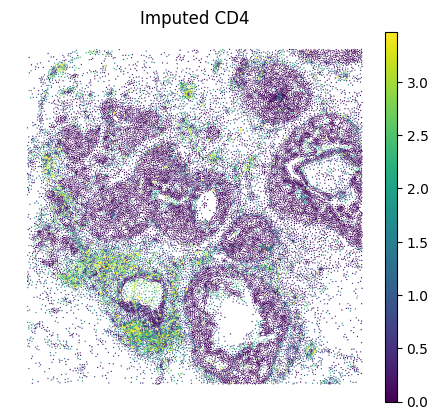

/tmp/ipykernel_3782834/3359475827.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_imputed_A, layer="log1p_norm",   color=GENE, spot_size=10, vmax="p99", frameon=False, title=f"Observed {GENE}")


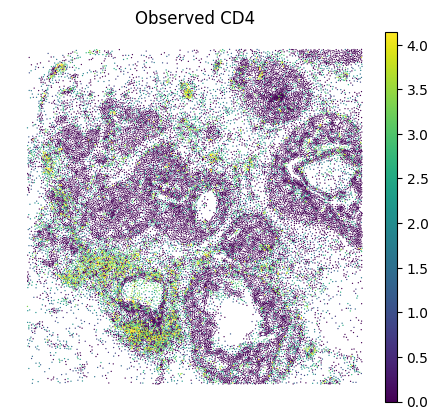

In [18]:
# Spatial plots — edit gene name as needed
GENE = "CD4"
sc.pl.spatial(adata_imputed_A, layer="imputed_norm", color=GENE, spot_size=10, vmax="p99", frameon=False, title=f"Imputed {GENE}")
sc.pl.spatial(adata_imputed_A, layer="log1p_norm",   color=GENE, spot_size=10, vmax="p99", frameon=False, title=f"Observed {GENE}")

In [44]:
# Genes present in scRNA but not in spatial
sc_only_genes = [g for g in sc_genes if g not in set(sp_genes)]

print(f"scRNA-only genes: {len(sc_only_genes)}")



scRNA-only genes: 1000


Example: Look at B cell genes: CD19, MS4A1 was in the panel, FCRL1 and PAX5 is purely imputed

In [31]:
bcells = ["CD19","MS4A1","FCRL1","PAX5"]


Spatial plots for B cell markers:
Imputed:


/tmp/ipykernel_4062742/2686052049.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_imputed_A, layer="imputed_norm", color=bcells, spot_size=20, vmax="p99", frameon=False)


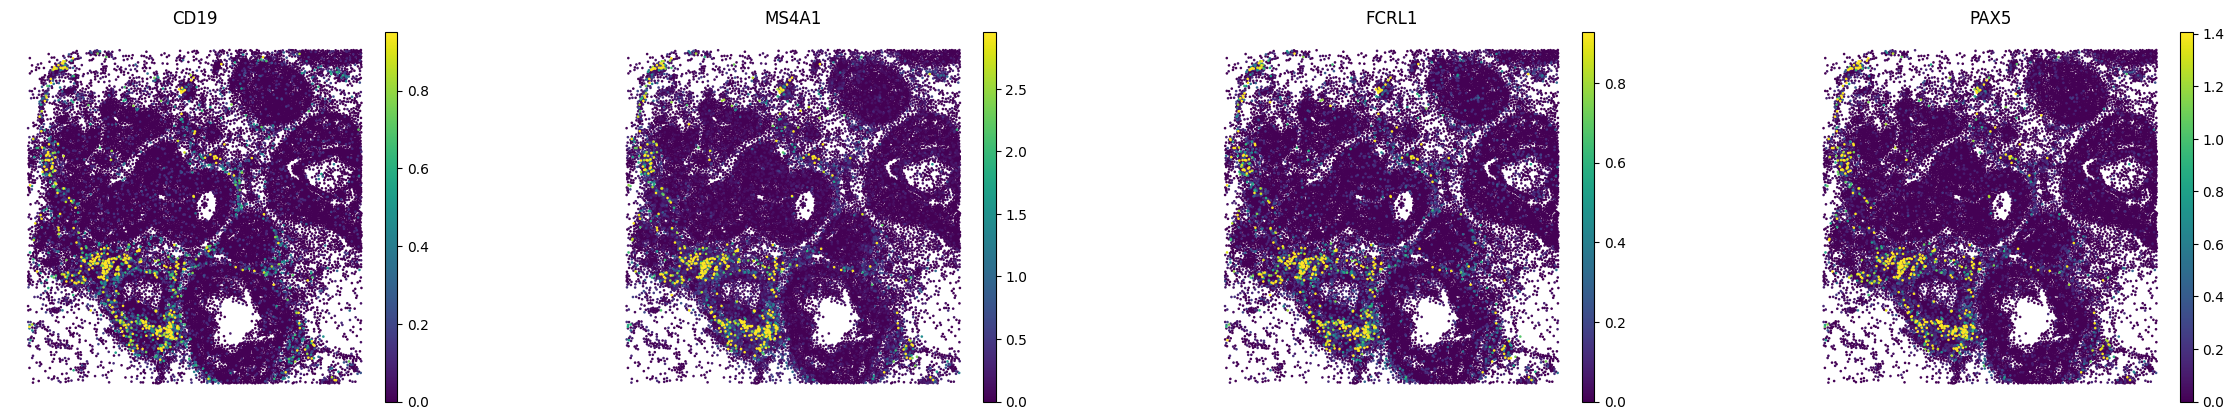

Measured:


/tmp/ipykernel_4062742/2686052049.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_imputed_A, layer="log1p_norm",   color=bcells, spot_size=20, vmax="p99", frameon=False,)


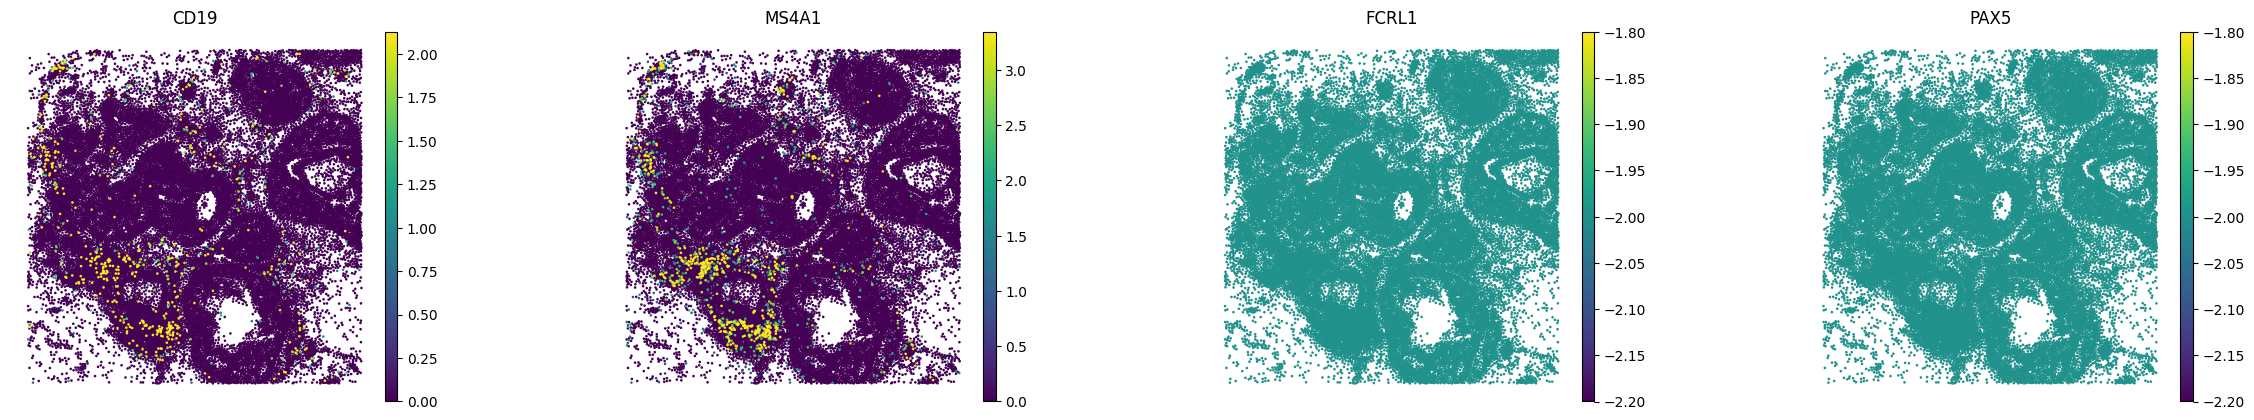

In [32]:
print("\nSpatial plots for B cell markers:")
print("Imputed:")
sc.pl.spatial(adata_imputed_A, layer="imputed_norm", color=bcells, spot_size=20, vmax="p99", frameon=False)
print("Measured:")
sc.pl.spatial(adata_imputed_A, layer="log1p_norm",   color=bcells, spot_size=20, vmax="p99", frameon=False,)


UMAP plots for B cell markers:
Imputed:


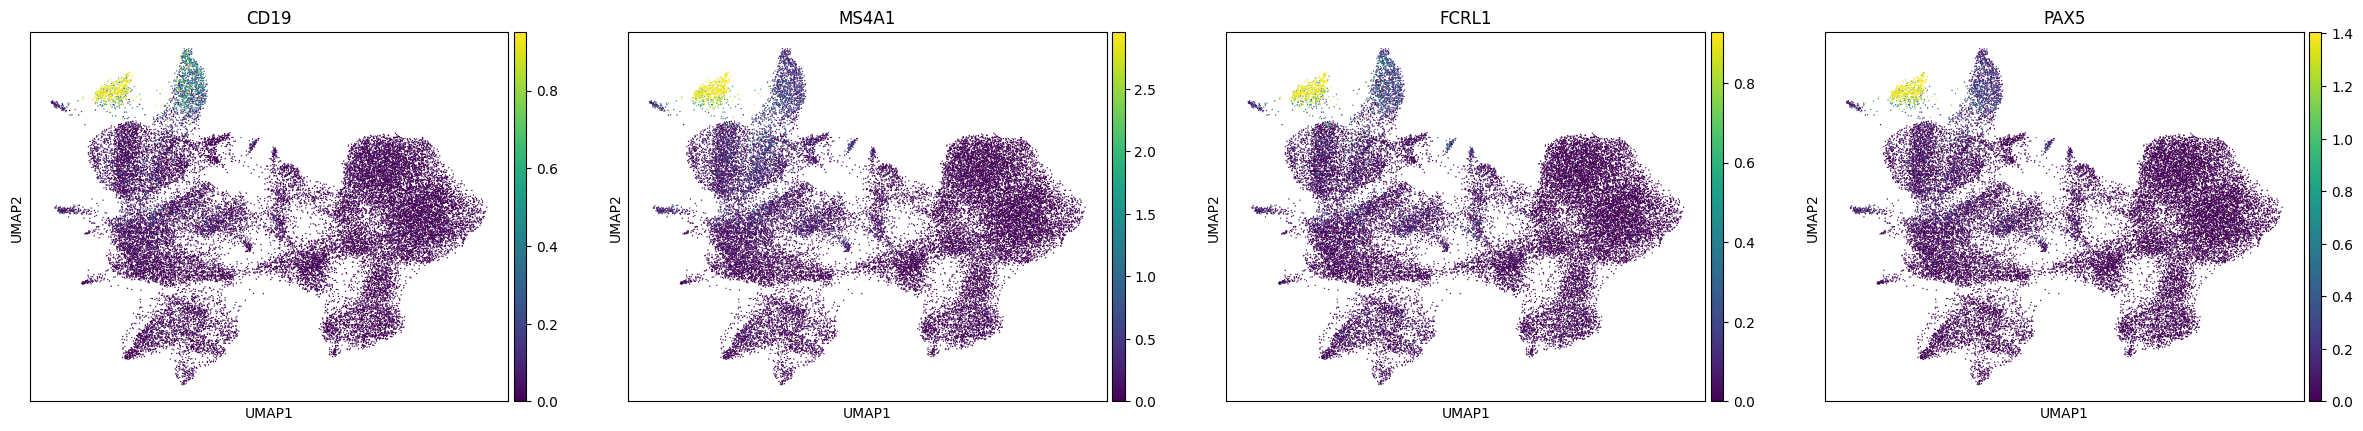

Measured:


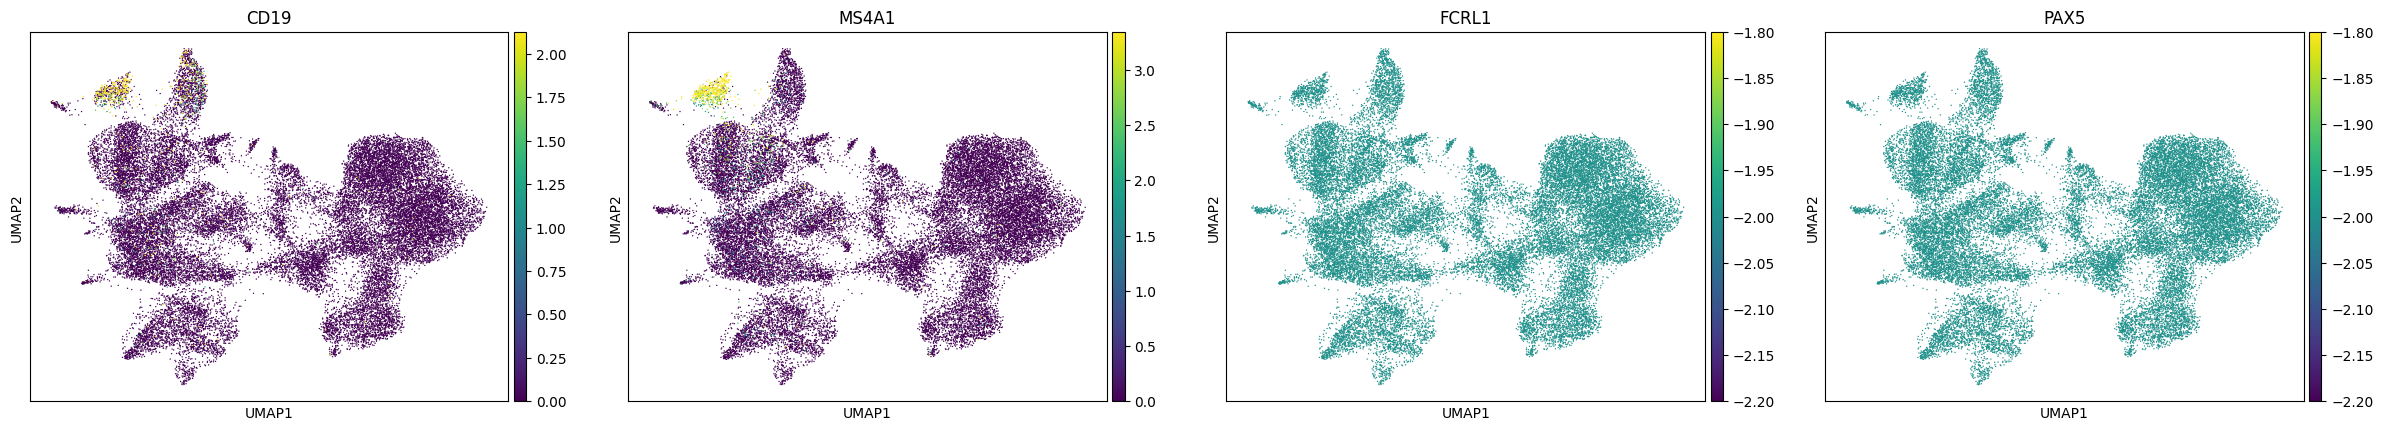

In [33]:
sc.pp.neighbors(adata_imputed_A, use_rep="X_cellpin")
sc.tl.umap(adata_imputed_A)
print("\nUMAP plots for B cell markers:")
print("Imputed:")
sc.pl.umap(adata_imputed_A, color=bcells,layer="imputed_norm", vmax="p99")
print("Measured:")
sc.pl.umap(adata_imputed_A, color=bcells,layer="log1p_norm", vmax="p99")



---
# Option B — Held-out gene evaluation

Hold out a subset of panel genes before training.  
These genes are **removed from the spatial input** so the model never sees them,  
then imputed values are compared against the true measured counts as a quantitative benchmark.

Steps:
1. Randomly sample held-out genes from the overlapping panel.
2. Create a reduced spatial AnnData (panel minus held-out genes).
3. Run `setup`, train, impute as normal.
4. Evaluate Pearson on the held-out genes.

In [34]:
rng = np.random.default_rng(42)

# Overlap in sc_adata order — setup() sorts panel genes this way internally,
# so held-out splits derived here stay consistent with the model's gene ordering.
panel_genes_all = [g for g in sc_adata.var_names if g in set(sp_adata.var_names)]
print(f"Full panel size: {len(panel_genes_all)} genes")

# Hold out 10% of panel genes (or specify a list directly)
HOLDOUT_FRACTION = 0.10 
n_holdout = max(1, int(len(panel_genes_all) * HOLDOUT_FRACTION))
heldout_genes = rng.choice(panel_genes_all, size=n_holdout, replace=False).tolist()
training_genes = [g for g in panel_genes_all if g not in heldout_genes]

print(f"Held-out genes  : {n_holdout}  → {heldout_genes[:5]} ...")
print(f"Training panel  : {len(training_genes)} genes")

Full panel size: 307 genes
Held-out genes  : 30  → ['NDUFA4L2', 'CCDC6', 'LEP', 'CCL8', 'ELF3'] ...
Training panel  : 277 genes


In [35]:
# Spatial data seen by the model — held-out genes removed
sp_adata_reduced = sp_adata[:, training_genes].copy()

# Sanity: confirm no held-out genes leaked into the reduced dataset
assert len(set(heldout_genes) & set(sp_adata_reduced.var_names)) == 0, \
    "Held-out genes still present in reduced sp_adata!"
print(f"sp_adata_reduced : {sp_adata_reduced.n_obs:,} cells × {sp_adata_reduced.n_vars:,} genes (held-out genes removed ✓)")

sp_adata_reduced : 30,600 cells × 277 genes (held-out genes removed ✓)


In [36]:
# setup() will confirm gene order and print the overlap summary
sc_dataset_B, st_dataset_B = cellpin.pp.setup(sc_adata, sp_adata_reduced, layer=LAYER)

[cellpin.pp.setup] sc_adata : 23,867 cells × 1,307 genes
[cellpin.pp.setup] st_adata : 30,600 cells × 277 spatial genes
[cellpin.pp.setup] Panel    : 277 genes overlap (spatial ∩ scRNA) — these are the genes the model will use as input
[cellpin.pp.setup] Imputed  : 1,307 genes (full scRNA gene space)
[cellpin.pp.setup] Panel genes sorted to sc_adata position order ✓ (first 5: ['FBLIM1', 'C1QA', 'C1QC', 'TRAPPC3', 'SMAP2'])


In [37]:
model_B = cellpin.CellPin(sc_dataset_B, config=MODEL_CONFIG)
model_B.fit(sc_dataset_B, pretrain_epochs=50, train_epochs=60) 

/home/philipp/miniconda3/envs/cellpin_model/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
/home/philipp/miniconda3/envs/cellpin_model/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Epoch 21: 100%|██████████| 75/75 [00:07<00:00, 10.45it/s, v_num=5, val_loss=527.0, val_reconst_loss=440.0, val_kl_loss=58.20, val_kl_l_loss=2.470, val_distill_loss=0.0862, val_snn_loss=1.870, val_inv_loss=0.245, val_snn_temperature=0.126, val_pearson_loss=0.480, train_loss=538.0, train_reconst_loss=449.0, train_kl_loss=58.80, train_kl_l_loss=2.500, train_distill_loss=0.105, train_snn_loss=2.210, train_inv_loss=0.293, train_snn_temperature=0.127, train_pearson_loss=0.463] 


In [38]:
dl_B = torch.utils.data.DataLoader(st_dataset_B, batch_size=512, shuffle=False)

adata_imputed_B = model_B.impute(
    dl_B,
    obs_adata=sp_adata_reduced,
    return_norm=True,
    area_key="cell_area",   # set to None if not available
    nb_count_samples=20,
)
print(adata_imputed_B)

Embedding and imputing cells (MC, 50 samples)...
[CellPin.impute] Panel gene order confirmed ✓
  [impute] Filling 1030 gene(s) absent from obs_adata layers with sentinel -2.0
  [impute] Filling 1030 gene(s) absent from obs_adata layers with sentinel -2.0
AnnData object with n_obs × n_vars = 30600 × 1307
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region'
    obsm: 'X_cellpin', 'spatial'
    layers: 'counts', 'log1p_norm', 'imputed', 'imputed_norm'


In [39]:
# Pearson on training panel genes (observed ↔ imputed)
print("=== Training panel genes (count space) ===")
correlation_panel(adata_imputed_B, layer_real="counts", layer_imputed="imputed")

=== Training panel genes (count space) ===
Valid genes (no -2 sentinel): 277
Mean Pearson correlation    : 0.5861


np.float64(0.586137988626979)

In [40]:
# Pearson on held-out genes — the true imputation benchmark
# sp_adata (full) contains the ground-truth counts for held-out genes
print("=== Held-out genes (count space) ===")
correlation_heldout(
    adata_imputed_B,
    sp_adata_full=sp_adata,
    heldout_genes=heldout_genes,
    layer_real="counts",
    layer_imputed="imputed",
)

=== Held-out genes (count space) ===
  NDUFA4L2              Pearson = 0.1821
  CCDC6                 Pearson = 0.6124
  LEP                   Pearson = 0.3262
  CCL8                  Pearson = 0.2032
  ELF3                  Pearson = 0.6460
  ENAH                  Pearson = 0.4304
  TIMP4                 Pearson = 0.3264
  KRT14                 Pearson = 0.8000
  ITGAX                 Pearson = 0.7493
  LYZ                   Pearson = 0.7545
  GNLY                  Pearson = 0.5233
  CX3CR1                Pearson = 0.4831
  SPIB                  Pearson = 0.3905
  CXCL12                Pearson = 0.8175
  KRT23                 Pearson = 0.8236
  DNAAF1                Pearson = 0.0527
  AGR3                  Pearson = 0.6143
  FOXA1                 Pearson = 0.8594
  FOXP3                 Pearson = 0.2967
  PTN                   Pearson = 0.7827
  PDCD1LG2              Pearson = 0.2361
  CCND1                 Pearson = 0.7879
  SQLE                  Pearson = 0.4535
  ANKRD30A          

np.float64(0.5211350643475972)

In [41]:
# Pearson on held-out genes — the true imputation benchmark
# sp_adata (full) contains the ground-truth counts for held-out genes
print("=== Held-out genes (count space) ===")
correlation_heldout(
    adata_imputed_B,
    sp_adata_full=sp_adata,
    heldout_genes=heldout_genes,
    layer_real="log1p_norm",
    layer_imputed="imputed_norm",
)

=== Held-out genes (count space) ===
  NDUFA4L2              Pearson = 0.1653
  CCDC6                 Pearson = 0.5124
  LEP                   Pearson = 0.1350
  CCL8                  Pearson = 0.1598
  ELF3                  Pearson = 0.5611
  ENAH                  Pearson = 0.3458
  TIMP4                 Pearson = 0.1097
  KRT14                 Pearson = 0.7362
  ITGAX                 Pearson = 0.5859
  LYZ                   Pearson = 0.6490
  GNLY                  Pearson = 0.3958
  CX3CR1                Pearson = 0.3889
  SPIB                  Pearson = 0.3361
  CXCL12                Pearson = 0.7527
  KRT23                 Pearson = 0.7318
  DNAAF1                Pearson = 0.0209
  AGR3                  Pearson = 0.5702
  FOXA1                 Pearson = 0.8377
  FOXP3                 Pearson = 0.2794
  PTN                   Pearson = 0.7025
  PDCD1LG2              Pearson = 0.1495
  CCND1                 Pearson = 0.6647
  SQLE                  Pearson = 0.3171
  ANKRD30A          

np.float64(0.4327420973543797)

/tmp/ipykernel_4062742/643264478.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_imputed_B, layer="imputed_norm", color=GENES, spot_size=15, vmax="p99", frameon=False, title=f"Imputed {GENES} (held-out)")


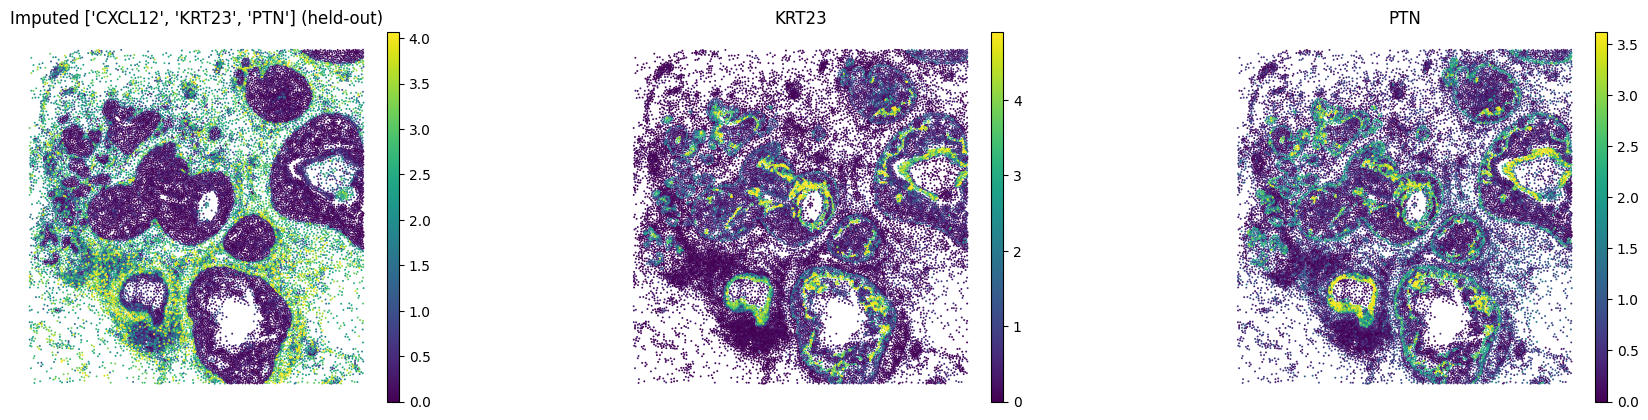

/tmp/ipykernel_4062742/643264478.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sp_adata, layer="log1p_norm",   color=GENES, spot_size=15, vmax="p99", frameon=False, title=f"Observed {GENES}")


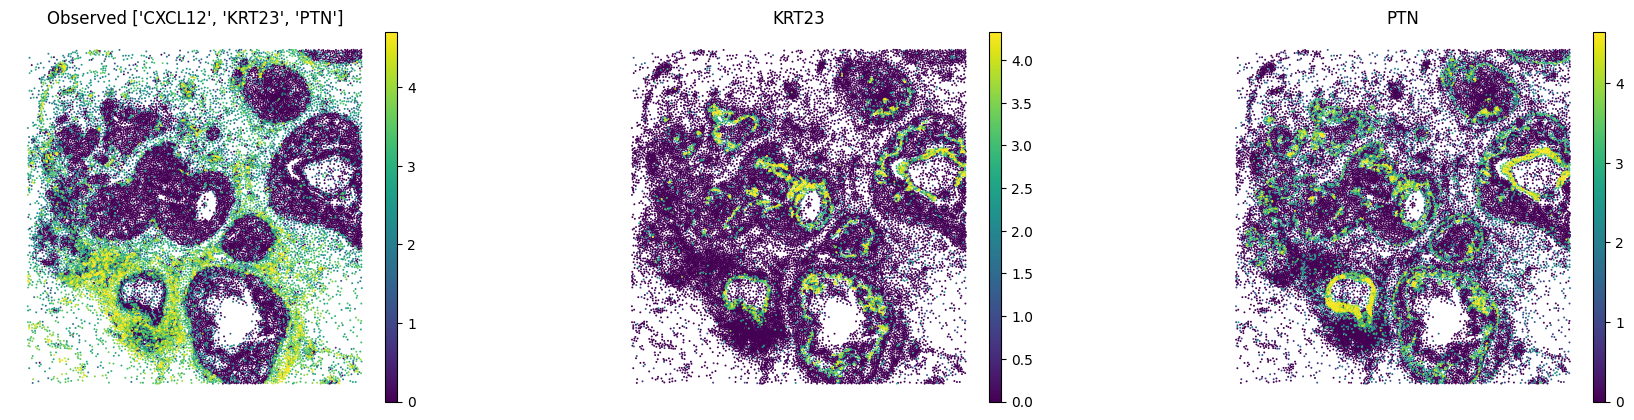

In [46]:
# Spatial plots — edit genes name as needed
GENES = ["CXCL12","KRT23","PTN"]  # example heldout genes with good imputation performance
sc.pl.spatial(adata_imputed_B, layer="imputed_norm", color=GENES, spot_size=15, vmax="p99", frameon=False, title=f"Imputed {GENES} (held-out)")
sc.pl.spatial(sp_adata, layer="log1p_norm",   color=GENES, spot_size=15, vmax="p99", frameon=False, title=f"Observed {GENES}")